In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, pearsonr
import warnings, os
warnings.filterwarnings('ignore')

In [2]:
# ── Style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
C_RED   = '#C0392B'
C_GREEN = '#1E8449'
C_AMBER = '#D68910'
C_BLUE  = '#1A5276'
C_PURPLE= '#6C3483'
C_LAKI  = '#2471A3'
C_PUAN  = '#B03A78'

os.makedirs('/content/business_analysis', exist_ok=True)

def save_fig(nama):
    path = f'/content/business_analysis/{nama}'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"✅ Tersimpan: {path}")

def smart_header(qnum, judul, s, m, a, r, t):
    """Cetak header SMART setiap pertanyaan."""
    print("\n" + "═"*70)
    print(f"  {qnum}: {judul}")
    print("═"*70)
    print(f"  S (Specific)   : {s}")
    print(f"  M (Measurable) : {m}")
    print(f"  A (Achievable) : {a}")
    print(f"  R (Relevant)   : {r}")
    print(f"  T (Time-bound) : {t}")
    print("─"*70)

In [3]:
# ── Load & persiapan ───────────────────────────────────────
df  = pd.read_csv('../data/processed/dataset_stunting_clean.csv')
who = pd.read_csv('../data/processed/who_reference_master.csv')

for col in ['usia_bulan','berat_badan','tinggi_badan',
            'zscore_bb_u','zscore_tb_u','zscore_bb_tb']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Merge WHO TB/U (LMS)
who_tbu = (who[who['indicator']=='TB/U']
        [['jenis_kelamin','month','l','m','s',
            'sd3neg','sd2neg','sd1neg','sd0','sd1','sd2','sd3']]
        .copy())
who_tbu.columns = ['jenis_kelamin','usia_bulan','l','m','s',
                'sd3neg','sd2neg','sd1neg','median_who',
                'sd1','sd2','sd3']
who_tbu['usia_bulan'] = who_tbu['usia_bulan'].astype(int)
df['usia_int'] = df['usia_bulan'].round().astype(int)
df = df.merge(who_tbu, left_on=['jenis_kelamin','usia_int'],
            right_on=['jenis_kelamin','usia_bulan'],
            how='left', suffixes=('','_who'))
df.drop(columns=['usia_bulan_who'], errors='ignore', inplace=True)

# Z-score WHO via LMS
def zscore_lms(row):
    try:
        X,L,M,S = row['tinggi_badan'],row['l'],row['m'],row['s']
        if any(pd.isna([X,L,M,S])): return np.nan
        return np.log(X/M)/S if L==0 else ((X/M)**L - 1)/(L*S)
    except: return np.nan

df['who_zscore'] = df.apply(zscore_lms, axis=1)
df['selisih_z']  = df['zscore_tb_u'] - df['who_zscore']

# Flag & kelompok
df['flag_stunting']   = (df['status_tb_u'] == 'Stunting').astype(int)
df['flag_gizi_buruk'] = df['status_bb_u'].isin(['Gizi Buruk','Gizi Kurang']).astype(int)
df['flag_kurus']      = df['status_bb_tb'].isin(['Kurus','Sangat Kurus']).astype(int)

bins  = [0,6,12,18,24,30,36,42,48,54,60]
label = ['0-6','6-12','12-18','18-24','24-30','30-36','36-42','42-48','48-54','54-60']
df['kelompok'] = pd.cut(df['usia_bulan'], bins=bins, labels=label, right=True)

print(f"✅ Data siap: {len(df):,} sampel")
print(f"   Stunting    : {df['flag_stunting'].sum():,} ({df['flag_stunting'].mean()*100:.1f}%)")
print(f"   Non-stunting: {(df['flag_stunting']==0).sum():,}")

✅ Data siap: 40,893 sampel
   Stunting    : 16,568 (40.5%)
   Non-stunting: 24,325


## **Q1** — Pada kelompok usia 6-bulanan mana (0–60 bln) prevalensi stunting tertinggi, dan apakah distribusi z-score TB/U berbeda signifikan antar 10 kelompok usia tersebut pada 40.066 sampel?

* S — Specific
10 kelompok usia 6-bulanan, prevalensi = % stunting per kelompok
* M — Measurable
Kruskal-Wallis α=0.05, H-statistik, p-value, prevalensi (%)
* A — Achievable
Kolom usia_bulan & status_tb_u tersedia lengkap, n=40.066
* R — Relevant
Menentukan window usia prioritas intervensi posyandu
* T — Time-bound
Dataset 40.066 balita usia 0–60 bulan





══════════════════════════════════════════════════════════════════════
  Q1: PREVALENSI STUNTING PER KELOMPOK USIA
══════════════════════════════════════════════════════════════════════
  S (Specific)   : 10 kelompok usia 6-bulanan (0–60 bln), prevalensi = % stunting per kelompok dari 40.066 sampel
  M (Measurable) : Kruskal-Wallis α=0.05 (H-statistik, p-value); prevalensi (%) per kelompok
  A (Achievable) : Kolom usia_bulan & status_tb_u tersedia lengkap tanpa missing
  R (Relevant)   : Menentukan window usia prioritas intervensi gizi dini untuk posyandu
  T (Time-bound) : Dataset 40.066 balita usia 0–60 bulan
──────────────────────────────────────────────────────────────────────

📌 Prevalensi tertinggi : kelompok 24-30 bulan
   → 47.47% (2,114 dari 4,453 anak)
   Rata-rata keseluruhan : 40.52%

📊 Kruskal-Wallis Test:
   H = 621.9171 | p = 4.13e-128
   ✅ SIGNIFIKAN: distribusi z-score berbeda nyata antar kelompok usia (p < 0.05)
✅ Tersimpan: /content/business_analysis/Q1_prevalensi_u

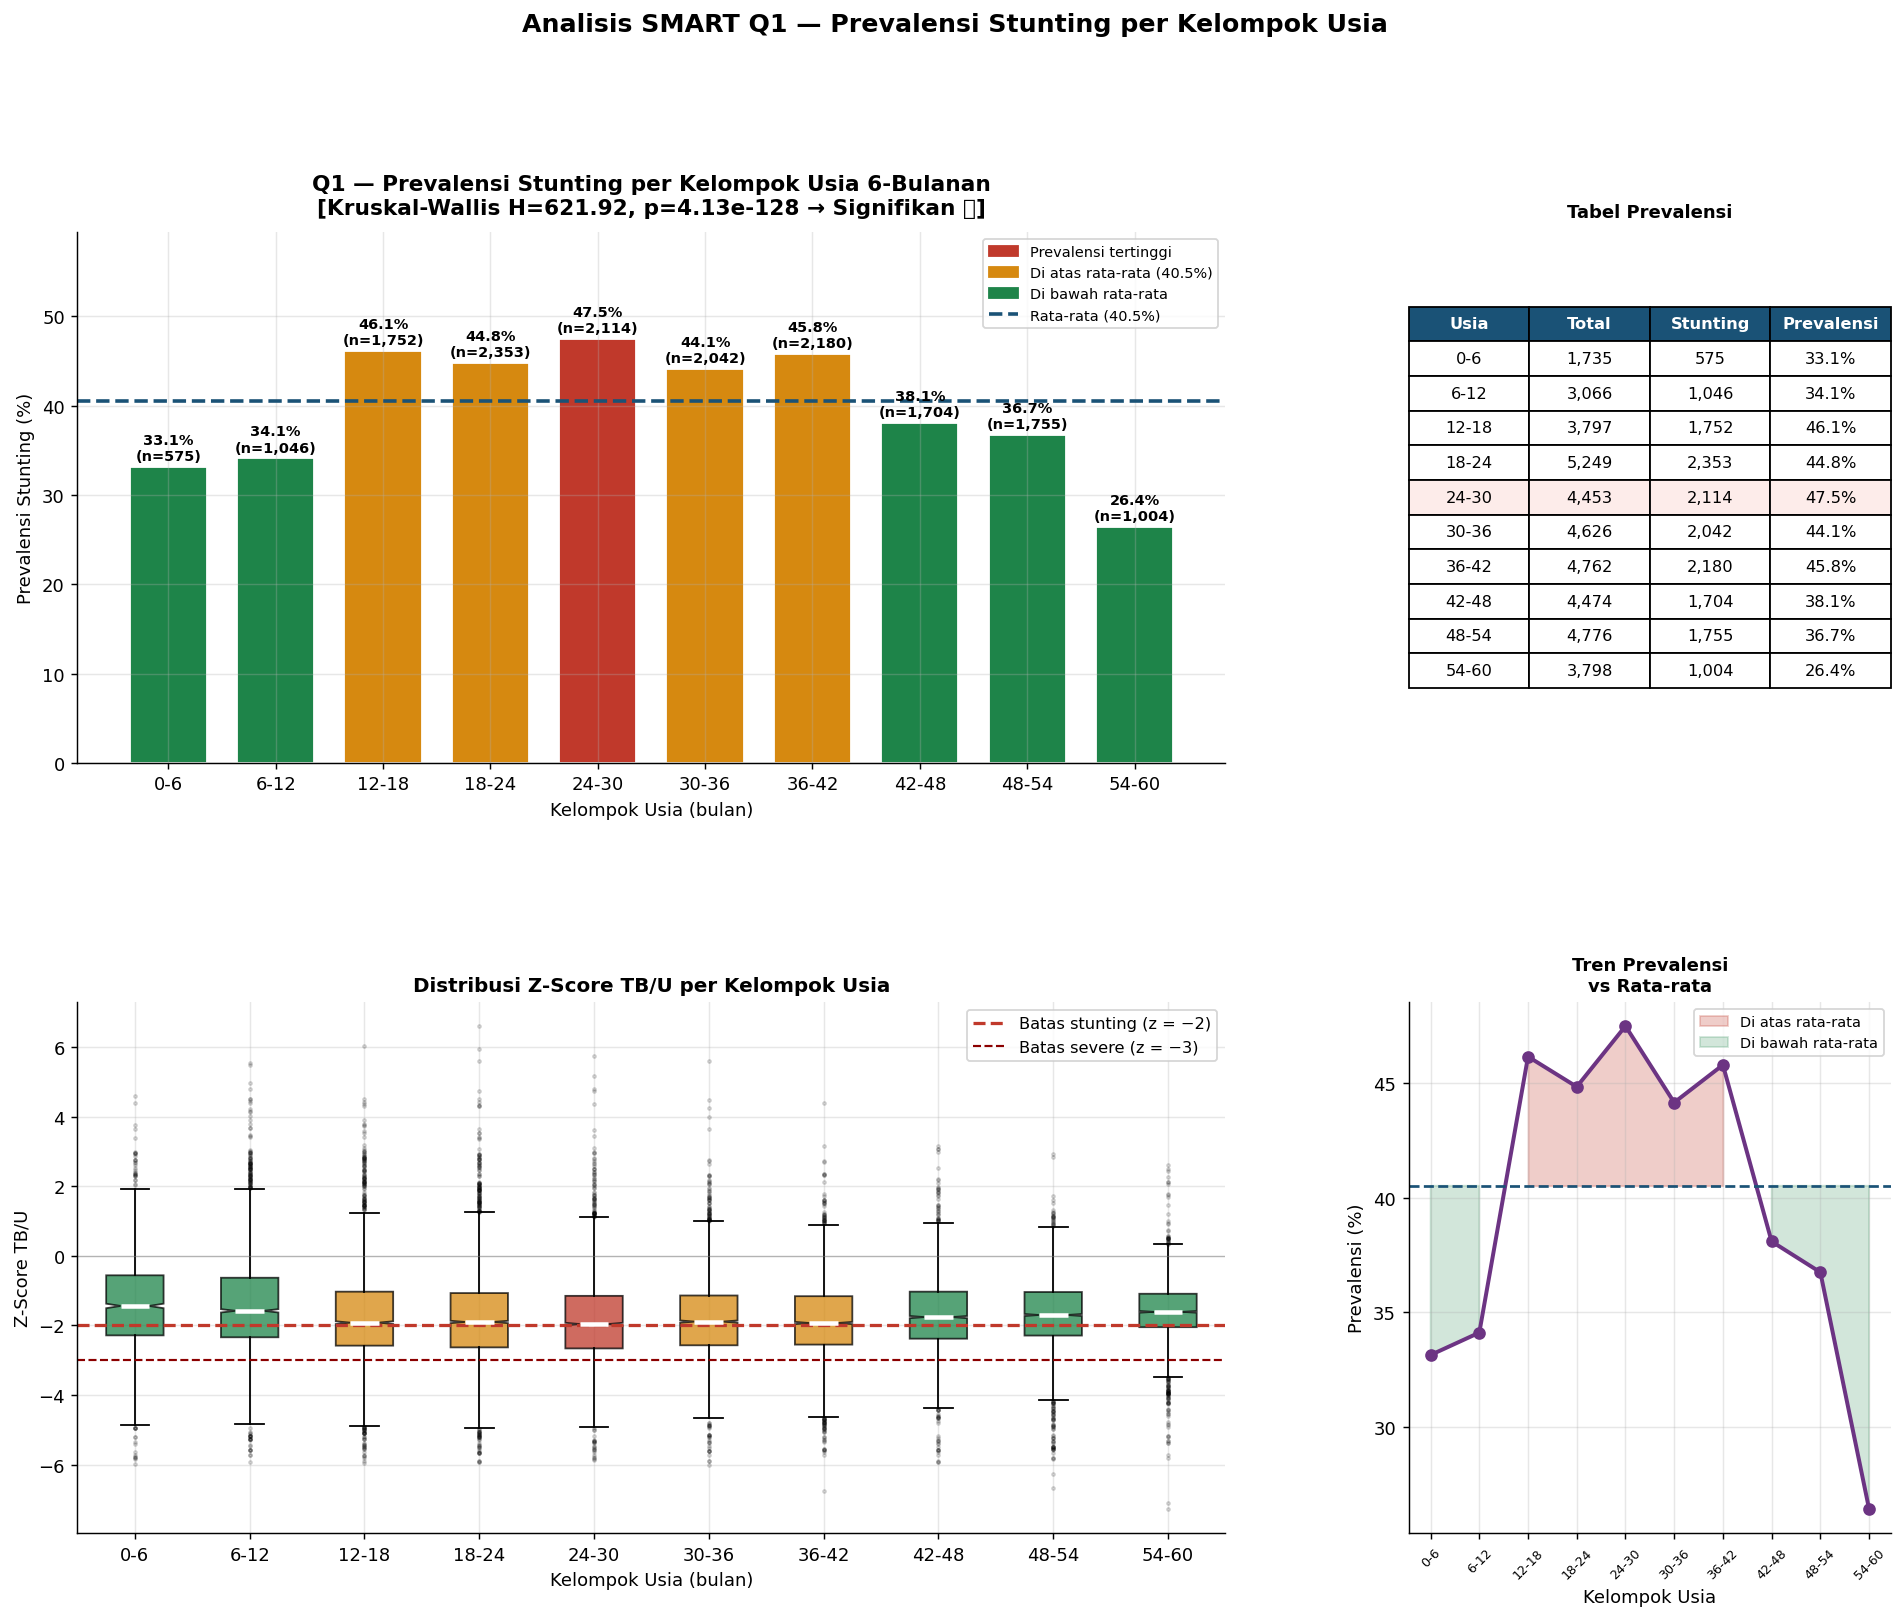

In [4]:
smart_header(
    "Q1", "PREVALENSI STUNTING PER KELOMPOK USIA",
    s="10 kelompok usia 6-bulanan (0–60 bln), prevalensi = % stunting per kelompok dari 40.066 sampel",
    m="Kruskal-Wallis α=0.05 (H-statistik, p-value); prevalensi (%) per kelompok",
    a="Kolom usia_bulan & status_tb_u tersedia lengkap tanpa missing",
    r="Menentukan window usia prioritas intervensi gizi dini untuk posyandu",
    t="Dataset 40.066 balita usia 0–60 bulan"
)

# ── Hitung prevalensi ──────────────────────────────────────
prev = (df.groupby('kelompok', observed=True)
        .agg(total=('flag_stunting','count'),
            stunting=('flag_stunting','sum'))
        .assign(prev_pct=lambda x: x['stunting']/x['total']*100)
        .reset_index())

rata2 = df['flag_stunting'].mean()*100
puncak = prev.loc[prev['prev_pct'].idxmax()]

# ── Uji Kruskal-Wallis ────────────────────────────────────
groups_z = [g['zscore_tb_u'].dropna().values
            for _, g in df.groupby('kelompok', observed=True)]
H, p_kw = kruskal(*groups_z)

print(f"\n📌 Prevalensi tertinggi : kelompok {puncak['kelompok']} bulan")
print(f"   → {puncak['prev_pct']:.2f}% ({int(puncak['stunting']):,} dari {int(puncak['total']):,} anak)")
print(f"   Rata-rata keseluruhan : {rata2:.2f}%")
print(f"\n📊 Kruskal-Wallis Test:")
print(f"   H = {H:.4f} | p = {p_kw:.2e}")
print(f"   {'✅ SIGNIFIKAN: distribusi z-score berbeda nyata antar kelompok usia (p < 0.05)' if p_kw < 0.05 else '❌ Tidak signifikan'}")

# ── Visualisasi ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1a. Bar prevalensi — span 2 kolom
ax1 = fig.add_subplot(gs[0, :2])
bar_colors = [C_RED if v==prev['prev_pct'].max()
            else C_AMBER if v>rata2 else C_GREEN
            for v in prev['prev_pct']]
bars = ax1.bar(prev['kelompok'].astype(str), prev['prev_pct'],
            color=bar_colors, edgecolor='white', width=0.72)
for bar, row in zip(bars, prev.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{row.prev_pct:.1f}%\n(n={int(row.stunting):,})",
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.axhline(rata2, color=C_BLUE, ls='--', lw=2,
            label=f'Rata-rata: {rata2:.1f}%')
ax1.set_title(f'Q1 — Prevalensi Stunting per Kelompok Usia 6-Bulanan\n'
            f'[Kruskal-Wallis H={H:.2f}, p={p_kw:.2e} → Signifikan ✅]',
            fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Prevalensi Stunting (%)')
ax1.set_xlabel('Kelompok Usia (bulan)')
ax1.set_ylim(0, prev['prev_pct'].max()+12)
p1 = mpatches.Patch(color=C_RED,   label='Prevalensi tertinggi')
p2 = mpatches.Patch(color=C_AMBER, label=f'Di atas rata-rata ({rata2:.1f}%)')
p3 = mpatches.Patch(color=C_GREEN, label='Di bawah rata-rata')
ax1.legend(handles=[p1,p2,p3,
        plt.Line2D([0],[0],color=C_BLUE,ls='--',lw=2)],
        labels=['Prevalensi tertinggi',f'Di atas rata-rata ({rata2:.1f}%)',
                'Di bawah rata-rata', f'Rata-rata ({rata2:.1f}%)'],
        fontsize=8, loc='upper right')

# 1b. Tabel ringkasan
ax_tbl = fig.add_subplot(gs[0, 2])
ax_tbl.axis('off')
tbl_data = [[row.kelompok, f"{row.total:,}",
            f"{int(row.stunting):,}", f"{row.prev_pct:.1f}%"]
            for row in prev.itertuples()]
tbl = ax_tbl.table(cellText=tbl_data,
                colLabels=['Usia','Total','Stunting','Prevalensi'],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for j in range(4):
    tbl[0,j].set_facecolor(C_BLUE)
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(tbl_data)+1):
    color = '#FDECEA' if tbl_data[i-1][3] == f"{puncak['prev_pct']:.1f}%" else 'white'
    for j in range(4): tbl[i,j].set_facecolor(color)
ax_tbl.set_title('Tabel Prevalensi', fontsize=10, fontweight='bold', pad=8)

# 1c. Boxplot z-score per kelompok
ax2 = fig.add_subplot(gs[1, :2])
data_box = [g['zscore_tb_u'].dropna().values
            for _, g in df.groupby('kelompok', observed=True)]
bp = ax2.boxplot(data_box, patch_artist=True, notch=True,
                 labels=prev['kelompok'].astype(str),
                 medianprops=dict(color='white', lw=2.5),
                 flierprops=dict(marker='.', ms=3, alpha=0.2))
for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax2.axhline(-2, color=C_RED,  ls='--', lw=1.8, label='Batas stunting (z = −2)')
ax2.axhline(-3, color='darkred',ls='--', lw=1.2, label='Batas severe (z = −3)')
ax2.axhline(0,  color='gray',  ls='-',  lw=0.7, alpha=0.5)
ax2.set_title('Distribusi Z-Score TB/U per Kelompok Usia', fontsize=11, fontweight='bold')
ax2.set_xlabel('Kelompok Usia (bulan)')
ax2.set_ylabel('Z-Score TB/U')
ax2.legend(fontsize=9)

# 1d. Tren area
ax3 = fig.add_subplot(gs[1, 2])
ax3.fill_between(prev['kelompok'].astype(str), prev['prev_pct'],
                 rata2, where=prev['prev_pct']>=rata2,
                 alpha=0.25, color=C_RED, label='Di atas rata-rata')
ax3.fill_between(prev['kelompok'].astype(str), prev['prev_pct'],
                 rata2, where=prev['prev_pct']<rata2,
                 alpha=0.2, color=C_GREEN, label='Di bawah rata-rata')
ax3.plot(prev['kelompok'].astype(str), prev['prev_pct'],
         'o-', color=C_PURPLE, lw=2.2, ms=6)
ax3.axhline(rata2, color=C_BLUE, ls='--', lw=1.5)
ax3.set_title('Tren Prevalensi\nvs Rata-rata', fontsize=10, fontweight='bold')
ax3.set_xlabel('Kelompok Usia')
ax3.set_ylabel('Prevalensi (%)')
ax3.tick_params(axis='x', rotation=45, labelsize=7)
ax3.legend(fontsize=8)

plt.suptitle('Analisis SMART Q1 — Prevalensi Stunting per Kelompok Usia',
             fontsize=14, fontweight='bold', y=1.01)
save_fig('Q1_prevalensi_usia.png')
plt.show()

## **Q2**— Apakah proporsi stunting pada 21.986 balita laki-laki berbeda secara statistik dari 18.080 balita perempuan usia 0–60 bulan, sebagai landasan strategi intervensi berbasis gender?

* S — Specific
Proporsi stunting laki-laki vs perempuan, usia 0–60 bulan
* M — Measurable
Chi-Square α=0.05 + Cramér's V + selisih persentase absolut
* A — Achievable
Kolom jenis_kelamin & status_tb_u tersedia tanpa missing
* R — Relevant
Apakah rekomendasi web app perlu dibedakan per gender?
* T — Time-bound
Dataset 40.066 sampel yang sama


══════════════════════════════════════════════════════════════════════
  Q2: PERBEDAAN STUNTING BERDASARKAN JENIS KELAMIN
══════════════════════════════════════════════════════════════════════
  S (Specific)   : Proporsi stunting pada 21.986 laki-laki vs 18.080 perempuan usia 0–60 bulan
  M (Measurable) : Chi-Square α=0.05 + Cramér's V (ukuran efek) + selisih % absolut
  A (Achievable) : Kolom jenis_kelamin & status_tb_u tersedia lengkap tanpa missing
  R (Relevant)   : Menentukan apakah rekomendasi web app perlu strategi berbeda per gender
  T (Time-bound) : Dataset 40.066 sampel usia 0–60 bulan
──────────────────────────────────────────────────────────────────────

📌 Prevalensi stunting:
   Laki-laki  : 42.55%
   Perempuan  : 38.05%
   Selisih    : 4.49 poin persentase

📊 Uji Chi-Square:
   χ² = 84.6433 | df = 1 | p = 0.000000
   Cramér's V = 0.0455  (0–0.1 lemah | 0.1–0.3 sedang | >0.3 kuat)
   ✅ SIGNIFIKAN (p < 0.05)
✅ Tersimpan: /content/business_analysis/Q2_gender.png


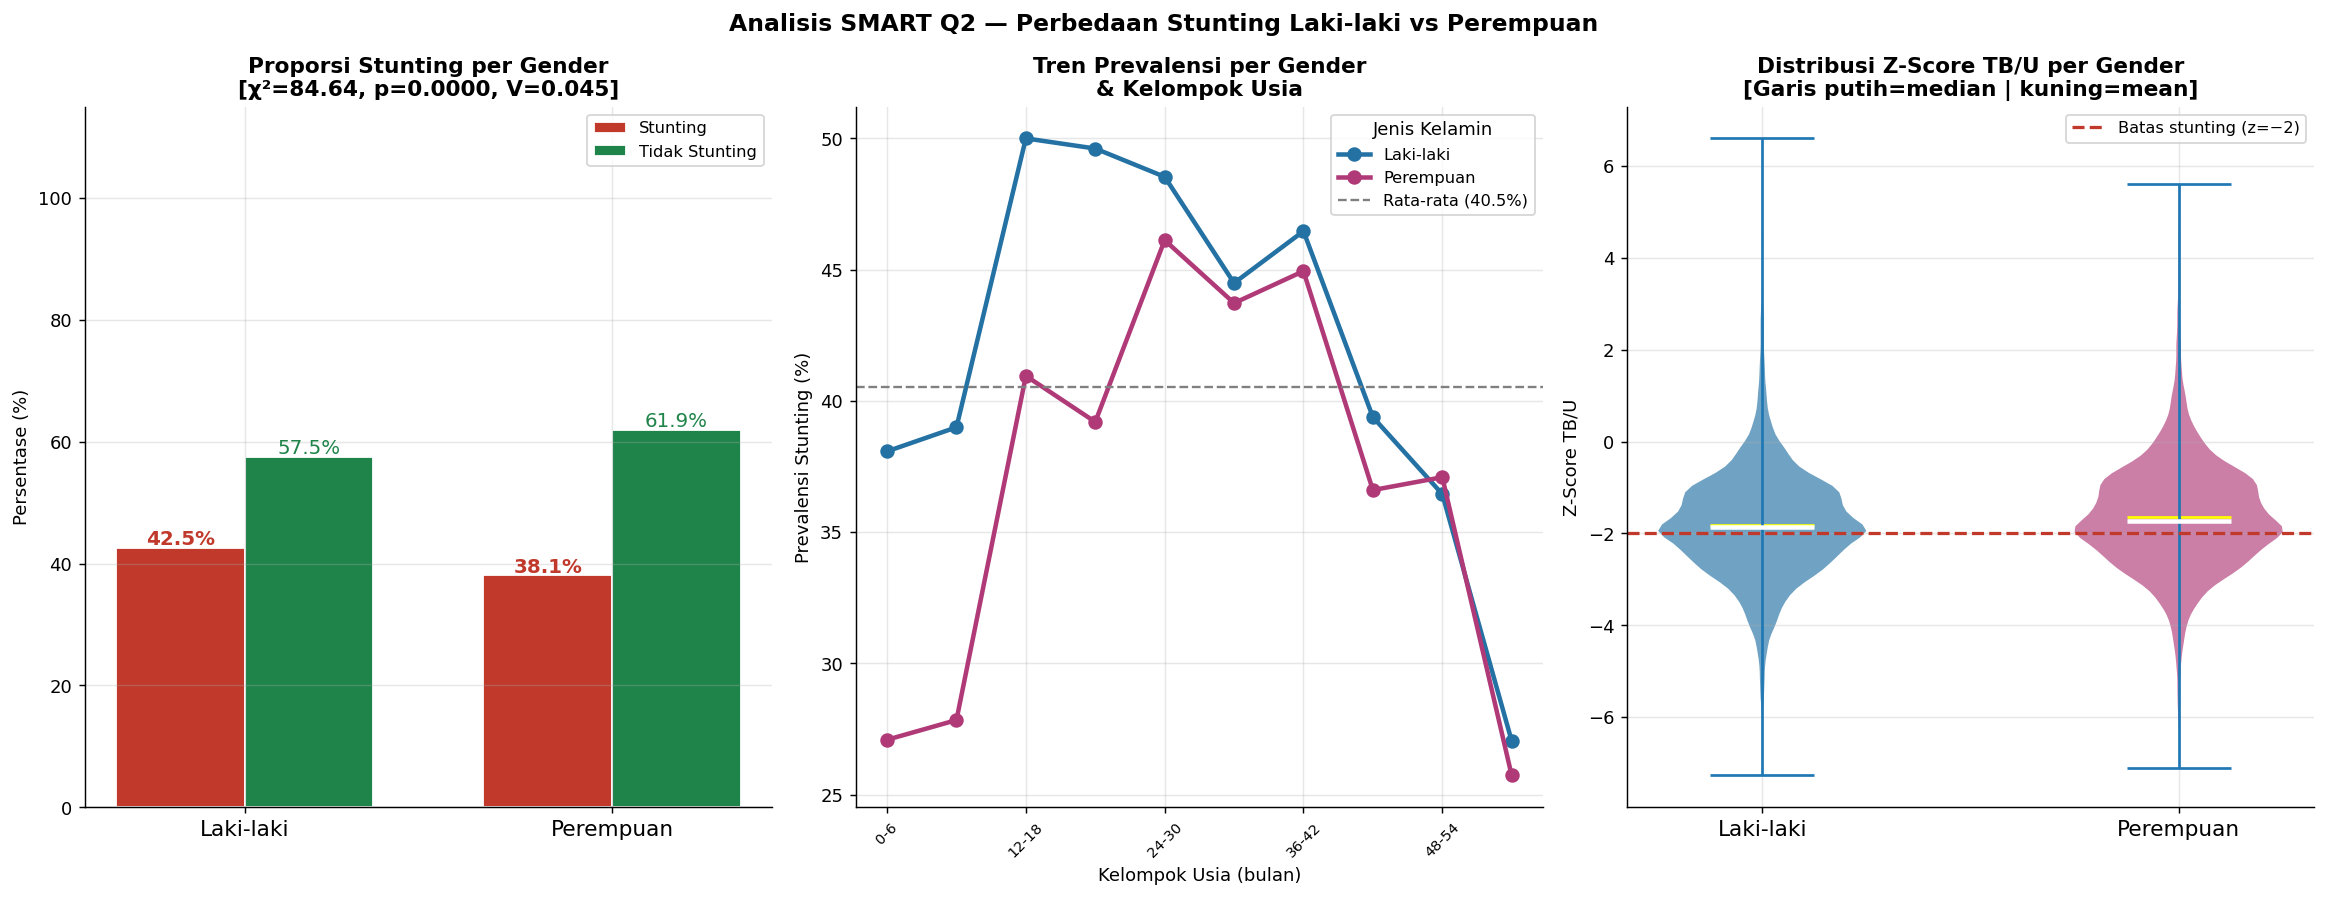

In [5]:
smart_header(
    "Q2", "PERBEDAAN STUNTING BERDASARKAN JENIS KELAMIN",
    s="Proporsi stunting pada 21.986 laki-laki vs 18.080 perempuan usia 0–60 bulan",
    m="Chi-Square α=0.05 + Cramér's V (ukuran efek) + selisih % absolut",
    a="Kolom jenis_kelamin & status_tb_u tersedia lengkap tanpa missing",
    r="Menentukan apakah rekomendasi web app perlu strategi berbeda per gender",
    t="Dataset 40.066 sampel usia 0–60 bulan"
)

# ── Hitung proporsi ───────────────────────────────────────
gp = (df.groupby('jenis_kelamin')
        .agg(total=('flag_stunting','count'),
             stunting=('flag_stunting','sum'))
        .assign(pct=lambda x: x['stunting']/x['total']*100,
                normal=lambda x: 100 - x['stunting']/x['total']*100)
        .reset_index())

laki_pct = gp[gp['jenis_kelamin']=='Laki-laki']['pct'].values[0]
puan_pct = gp[gp['jenis_kelamin']=='Perempuan']['pct'].values[0]

# ── Chi-Square + Cramér's V ───────────────────────────────
ct = pd.crosstab(df['jenis_kelamin'], df['flag_stunting'])
chi2, p_chi, dof, _ = chi2_contingency(ct)
n   = ct.values.sum()
V   = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"\n📌 Prevalensi stunting:")
print(f"   Laki-laki  : {laki_pct:.2f}%")
print(f"   Perempuan  : {puan_pct:.2f}%")
print(f"   Selisih    : {abs(laki_pct-puan_pct):.2f} poin persentase")
print(f"\n📊 Uji Chi-Square:")
print(f"   χ² = {chi2:.4f} | df = {dof} | p = {p_chi:.6f}")
print(f"   Cramér's V = {V:.4f}  (0–0.1 lemah | 0.1–0.3 sedang | >0.3 kuat)")
print(f"   {'✅ SIGNIFIKAN (p < 0.05)' if p_chi < 0.05 else '❌ Tidak signifikan'}")

# ── Visualisasi ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 2a. Grouped bar stunting/normal per gender
x, w = np.arange(2), 0.35
bars_s = axes[0].bar(x-w/2, gp['pct'],    w, color=C_RED,  label='Stunting',      edgecolor='white')
bars_n = axes[0].bar(x+w/2, gp['normal'], w, color=C_GREEN, label='Tidak Stunting', edgecolor='white')
for bar, v in zip(bars_s, gp['pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=11, fontweight='bold', color=C_RED)
for bar, v in zip(bars_n, gp['normal']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=11, color=C_GREEN)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Laki-laki','Perempuan'], fontsize=12)
axes[0].set_ylabel('Persentase (%)')
axes[0].set_ylim(0, 115)
axes[0].set_title(f'Proporsi Stunting per Gender\n[χ²={chi2:.2f}, p={p_chi:.4f}, V={V:.3f}]',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# 2b. Tren prevalensi per gender per kelompok usia
pgu = (df.groupby(['kelompok','jenis_kelamin'], observed=True)
         ['flag_stunting'].mean().unstack()*100)
pgu.plot(kind='line', ax=axes[1],
         color=[C_LAKI, C_PUAN], marker='o', lw=2.5, ms=7)
axes[1].axhline(rata2, color='gray', ls='--', lw=1.3,
                label=f'Rata-rata ({rata2:.1f}%)')
axes[1].set_title('Tren Prevalensi per Gender\n& Kelompok Usia', fontweight='bold')
axes[1].set_xlabel('Kelompok Usia (bulan)')
axes[1].set_ylabel('Prevalensi Stunting (%)')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend(title='Jenis Kelamin', fontsize=9)

# 2c. Violin plot z-score per gender
vp = axes[2].violinplot(
    [df[df['jenis_kelamin']=='Laki-laki']['zscore_tb_u'].dropna().values,
     df[df['jenis_kelamin']=='Perempuan']['zscore_tb_u'].dropna().values],
    positions=[1, 2], showmedians=True, showmeans=True
)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor([C_LAKI, C_PUAN][i]); pc.set_alpha(0.65)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
vp['cmeans'].set_color('yellow');  vp['cmeans'].set_linewidth(1.5)
axes[2].axhline(-2, color=C_RED, ls='--', lw=1.8, label='Batas stunting (z=−2)')
axes[2].set_xticks([1,2])
axes[2].set_xticklabels(['Laki-laki','Perempuan'], fontsize=12)
axes[2].set_ylabel('Z-Score TB/U')
axes[2].set_title('Distribusi Z-Score TB/U per Gender\n[Garis putih=median | kuning=mean]',
                  fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Analisis SMART Q2 — Perbedaan Stunting Laki-laki vs Perempuan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Q2_gender.png')
plt.show()

##**Q3** — Seberapa jauh rata-rata z-score TB/U per kelompok usia pada dataset menyimpang dari kalkulasi standar WHO (metode LMS, who_reference_master.csv), untuk menilai akurasi pengukuran lapangan?

* S — Specific
Selisih z-score aktual dataset vs kalkulasi ulang WHO per kelompok usia
* M — Measurable
Mean selisih, std, MAD, korelasi Pearson, ±95% CI
* A — Achievable
WHO LMS tersedia 0–60 bln, semua gender, semua indikator
* R — Relevant
Validasi kualitas data lapangan → kepercayaan model AI
*T — Time-bound
Seluruh periode pengumpulan dataset (0–60 bulan)


══════════════════════════════════════════════════════════════════════
  Q3: DEVIASI Z-SCORE DATASET vs STANDAR WHO
══════════════════════════════════════════════════════════════════════
  S (Specific)   : Selisih rata-rata z-score TB/U aktual vs kalkulasi WHO (LMS) per 10 kelompok usia
  M (Measurable) : Mean selisih, std, MAD, Korelasi Pearson, ±95% CI per kelompok
  A (Achievable) : WHO LMS tersedia 0–60 bulan untuk semua gender via who_reference_master.csv
  R (Relevant)   : Memvalidasi akurasi pengukuran lapangan → kepercayaan model AI
  T (Time-bound) : Seluruh periode pengumpulan dataset (0–60 bulan)
──────────────────────────────────────────────────────────────────────

📌 Korelasi Pearson (z dataset vs z WHO): r = 0.9808, p = 0.00e+00
   ✅ Korelasi sangat kuat

📌 Kelompok usia paling menyimpang: 0-6 bulan
   MAD = 0.5220 SD | Selisih = -0.5220

📋 Tabel selisih z-score per kelompok usia:
kelompok  mean_data  mean_who  mean_sel   ci95
     0-6    -1.3848   -0.8628   -0.5220 0.02

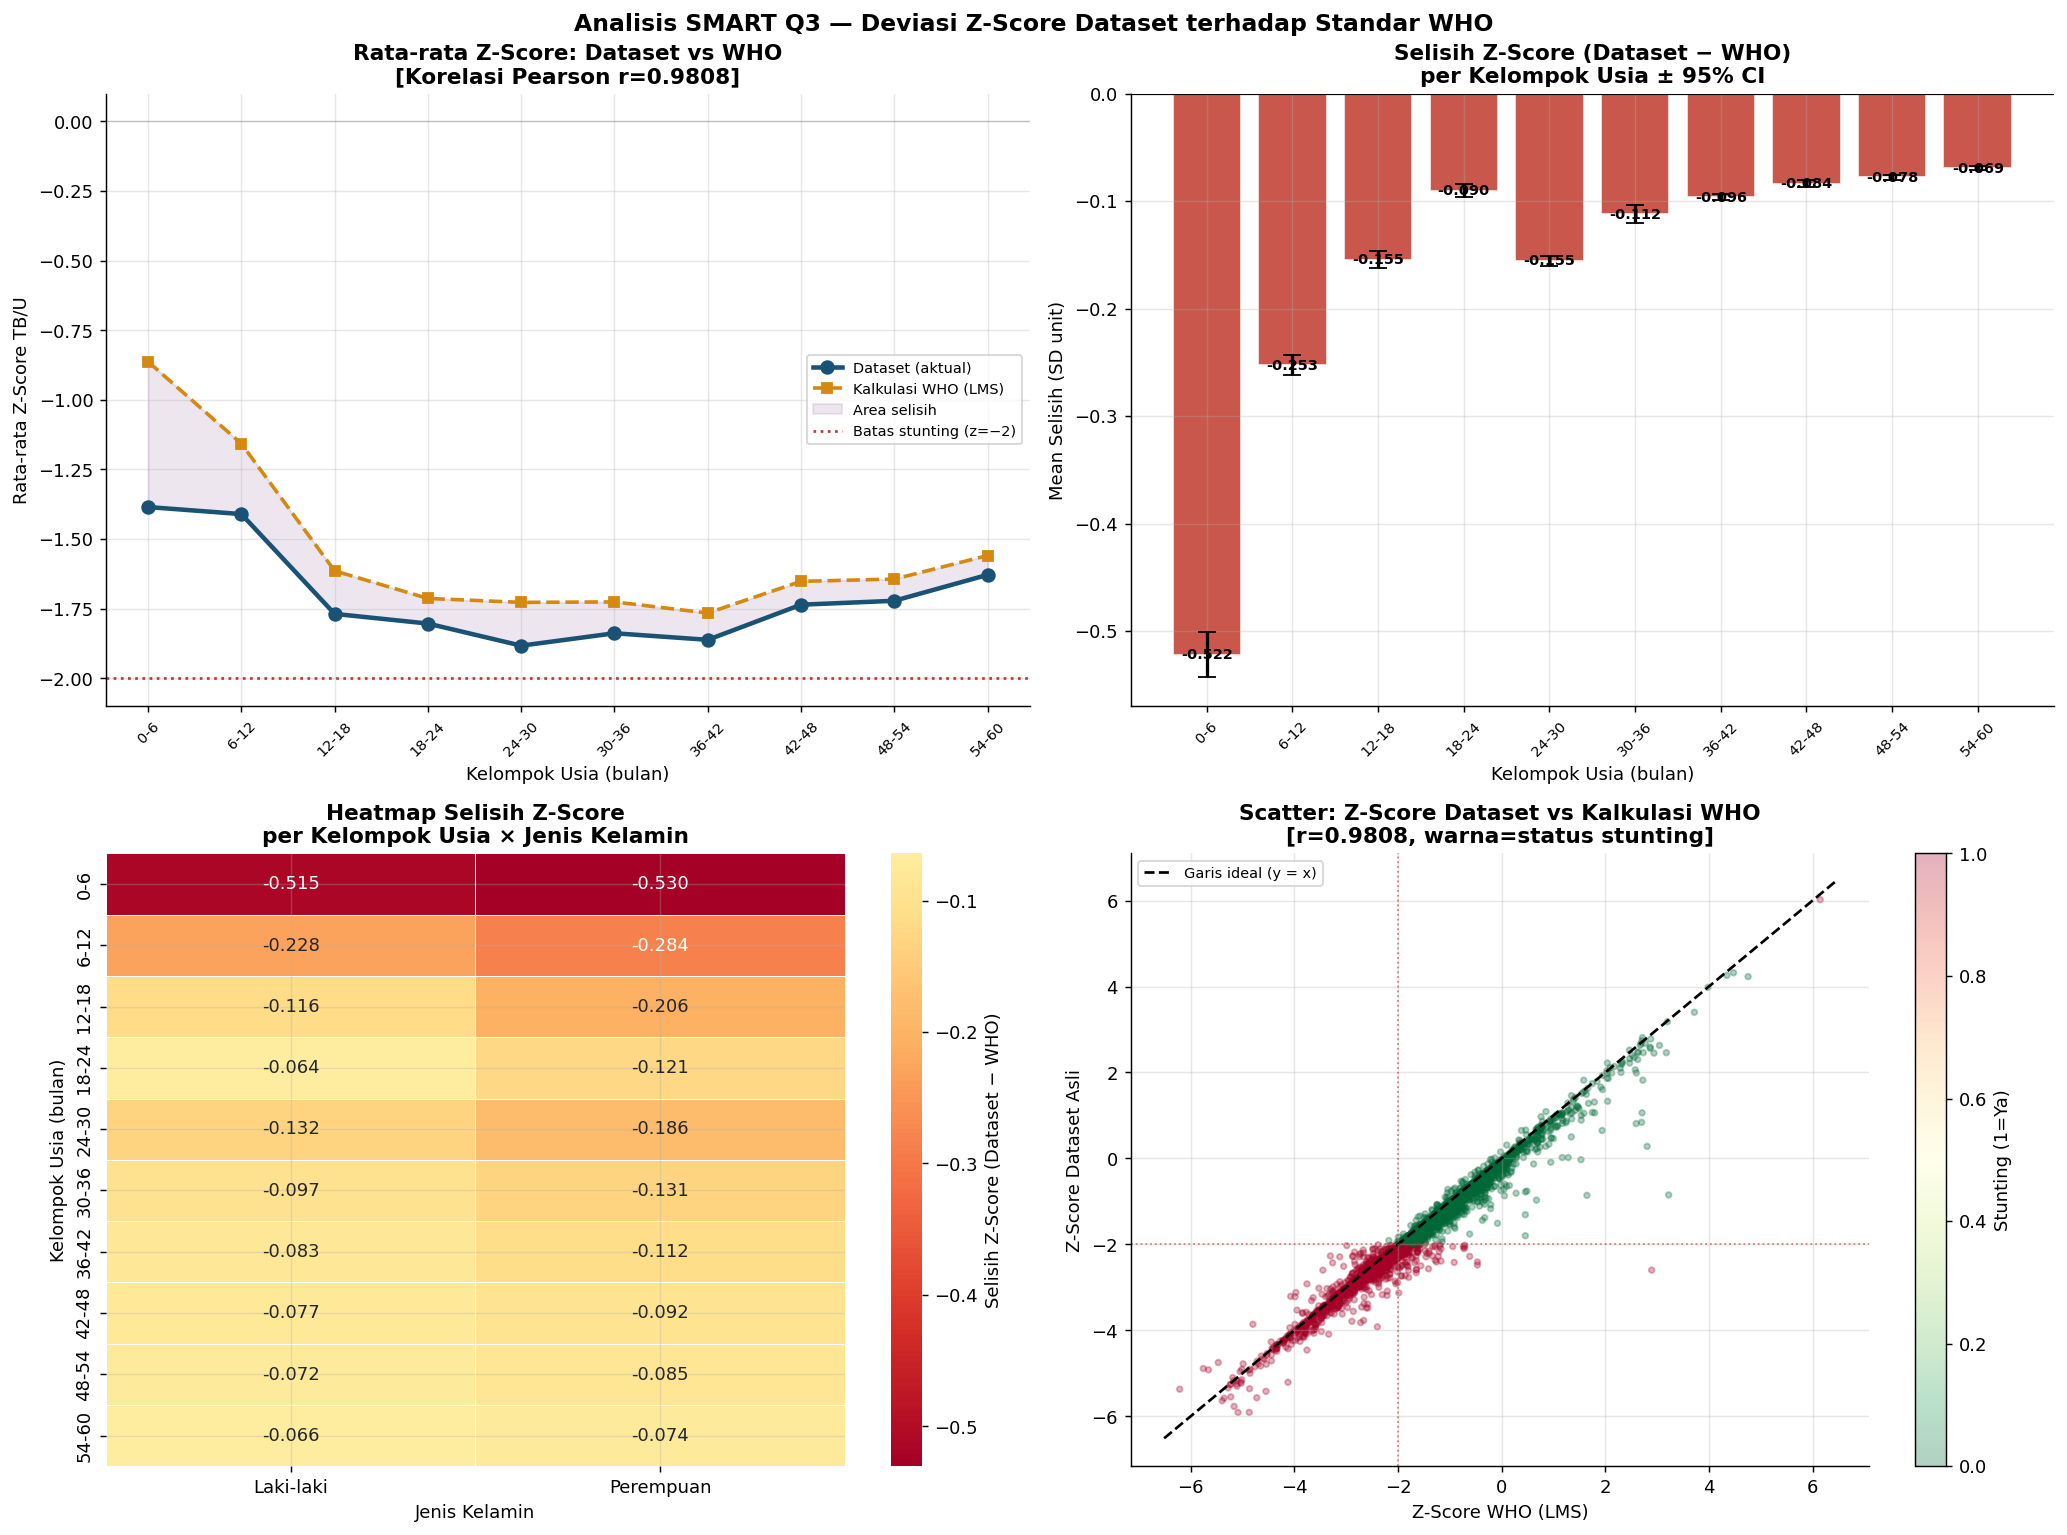

In [6]:
smart_header(
    "Q3", "DEVIASI Z-SCORE DATASET vs STANDAR WHO",
    s="Selisih rata-rata z-score TB/U aktual vs kalkulasi WHO (LMS) per 10 kelompok usia",
    m="Mean selisih, std, MAD, Korelasi Pearson, ±95% CI per kelompok",
    a="WHO LMS tersedia 0–60 bulan untuk semua gender via who_reference_master.csv",
    r="Memvalidasi akurasi pengukuran lapangan → kepercayaan model AI",
    t="Seluruh periode pengumpulan dataset (0–60 bulan)"
)

dev = (df.groupby('kelompok', observed=True)
         .agg(mean_data=('zscore_tb_u','mean'),
              mean_who =('who_zscore','mean'),
              mean_sel =('selisih_z','mean'),
              std_sel  =('selisih_z','std'),
              n        =('zscore_tb_u','count'))
         .assign(ci95=lambda x: 1.96*x['std_sel']/np.sqrt(x['n']),
                 mad =lambda x: x['mean_sel'].abs())
         .reset_index())

r, p_r = pearsonr(df['zscore_tb_u'].dropna(),
                  df['who_zscore'].loc[df['zscore_tb_u'].notna()])
maks = dev.loc[dev['mad'].idxmax()]

print(f"\n📌 Korelasi Pearson (z dataset vs z WHO): r = {r:.4f}, p = {p_r:.2e}")
print(f"   {'✅ Korelasi sangat kuat' if r>0.95 else '⚠️ Korelasi moderat'}")
print(f"\n📌 Kelompok usia paling menyimpang: {maks['kelompok']} bulan")
print(f"   MAD = {maks['mad']:.4f} SD | Selisih = {maks['mean_sel']:+.4f}")
print(f"\n📋 Tabel selisih z-score per kelompok usia:")
print(dev[['kelompok','mean_data','mean_who','mean_sel','ci95']].round(4).to_string(index=False))

# ── Visualisasi ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3a. Z-score dataset vs WHO
axes[0,0].plot(dev['kelompok'].astype(str), dev['mean_data'],
               'o-', color=C_BLUE, lw=2.5, ms=7, label='Dataset (aktual)')
axes[0,0].plot(dev['kelompok'].astype(str), dev['mean_who'],
               's--', color=C_AMBER, lw=2, ms=6, label='Kalkulasi WHO (LMS)')
axes[0,0].fill_between(dev['kelompok'].astype(str),
                        dev['mean_data'], dev['mean_who'],
                        alpha=0.12, color=C_PURPLE, label='Area selisih')
axes[0,0].axhline(-2, color=C_RED, ls=':', lw=1.5, label='Batas stunting (z=−2)')
axes[0,0].axhline(0, color='gray', ls='-', lw=0.7, alpha=0.4)
axes[0,0].set_title(f'Rata-rata Z-Score: Dataset vs WHO\n[Korelasi Pearson r={r:.4f}]',
                    fontweight='bold')
axes[0,0].set_ylabel('Rata-rata Z-Score TB/U')
axes[0,0].set_xlabel('Kelompok Usia (bulan)')
axes[0,0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0,0].legend(fontsize=8)

# 3b. Bar selisih ± CI
col_bar = [C_RED if v<0 else C_GREEN for v in dev['mean_sel']]
axes[0,1].bar(dev['kelompok'].astype(str), dev['mean_sel'],
              color=col_bar, edgecolor='white', alpha=0.85)
axes[0,1].errorbar(dev['kelompok'].astype(str), dev['mean_sel'],
                   yerr=dev['ci95'], fmt='none', color='black',
                   capsize=5, lw=1.8)
axes[0,1].axhline(0, color='black', lw=1.2)
for i, row in dev.iterrows():
    axes[0,1].text(i, row['mean_sel'] + (0.002 if row['mean_sel']>=0 else -0.004),
                   f"{row['mean_sel']:+.3f}", ha='center', fontsize=8, fontweight='bold')
axes[0,1].set_title('Selisih Z-Score (Dataset − WHO)\nper Kelompok Usia ± 95% CI',
                    fontweight='bold')
axes[0,1].set_ylabel('Mean Selisih (SD unit)')
axes[0,1].set_xlabel('Kelompok Usia (bulan)')
axes[0,1].tick_params(axis='x', rotation=45, labelsize=8)

# 3c. Heatmap deviasi usia × gender
pivot_dev = (df.groupby(['kelompok','jenis_kelamin'], observed=True)
               ['selisih_z'].mean().unstack())
sns.heatmap(pivot_dev, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[1,0], linewidths=0.5,
            cbar_kws={'label':'Selisih Z-Score (Dataset − WHO)'})
axes[1,0].set_title('Heatmap Selisih Z-Score\nper Kelompok Usia × Jenis Kelamin',
                    fontweight='bold')
axes[1,0].set_xlabel('Jenis Kelamin')
axes[1,0].set_ylabel('Kelompok Usia (bulan)')

# 3d. Scatter z-score dataset vs WHO
smp = df[['who_zscore','zscore_tb_u','flag_stunting']].dropna().sample(4000, random_state=42)
sc = axes[1,1].scatter(smp['who_zscore'], smp['zscore_tb_u'],
                       c=smp['flag_stunting'], cmap='RdYlGn_r',
                       alpha=0.3, s=10)
lim = [min(smp['who_zscore'].min(), smp['zscore_tb_u'].min()) - 0.3,
       max(smp['who_zscore'].max(), smp['zscore_tb_u'].max()) + 0.3]
axes[1,1].plot(lim, lim, 'k--', lw=1.5, label='Garis ideal (y = x)')
axes[1,1].axhline(-2, color=C_RED, ls=':', lw=1, alpha=0.6)
axes[1,1].axvline(-2, color=C_RED, ls=':', lw=1, alpha=0.6)
plt.colorbar(sc, ax=axes[1,1], label='Stunting (1=Ya)')
axes[1,1].set_title(f'Scatter: Z-Score Dataset vs Kalkulasi WHO\n[r={r:.4f}, warna=status stunting]',
                    fontweight='bold')
axes[1,1].set_xlabel('Z-Score WHO (LMS)')
axes[1,1].set_ylabel('Z-Score Dataset Asli')
axes[1,1].legend(fontsize=8)

plt.suptitle('Analisis SMART Q3 — Deviasi Z-Score Dataset terhadap Standar WHO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Q3_deviasi_who.png')
plt.show()

##**Q4** — Berapa proporsi dari 16.200 anak stunting yang sekaligus mengalami gizi buruk/kurang (BB/U) dan/atau kurus (BB/TB), dan apakah asosiasi ko-morbiditas tersebut signifikan secara statistik (α=0.05)?

* S — Specific
Ko-morbiditas 3 indikator gizi pada 40.066 sampel usia 0–60 bulan
* M — Measurable
Proporsi (%) ko-morbiditas + Chi-Square α=0.05 + Odds Ratio
* A — Achievable
Kolom status_bb_u, status_bb_tb, status_tb_u tersedia lengkap
* R — Relevant
Menentukan beban ganda gizi untuk pesan rekomendasi web app
* T — Time-bound
Dataset 40.066 sampel usia 0–60 bulan


══════════════════════════════════════════════════════════════════════
  Q4: KO-MORBIDITAS GIZI — STUNTING + GIZI BURUK + KURUS
══════════════════════════════════════════════════════════════════════
  S (Specific)   : Proporsi 16.200 anak stunting yang sekaligus gizi buruk/kurang (BB/U) dan/atau kurus (BB/TB)
  M (Measurable) : Proporsi (%) ko-morbiditas + Chi-Square α=0.05 + Odds Ratio antar pasangan indikator
  A (Achievable) : Kolom status_bb_u, status_bb_tb, status_tb_u tersedia di 40.066 baris
  R (Relevant)   : Menentukan beban ganda gizi untuk konten rekomendasi web app yang tepat sasaran
  T (Time-bound) : Dataset 40.066 sampel usia 0–60 bulan
──────────────────────────────────────────────────────────────────────

📌 Ko-morbiditas gizi:
              Kondisi  Jumlah    Persen
         Normal semua   22604 55.275964
        Stunting saja    8799 21.517130
Stunting + Gizi buruk    6346 15.518548
        Triple burden    1422  3.477368
   Gizi buruk + Kurus     720  1.760693
     

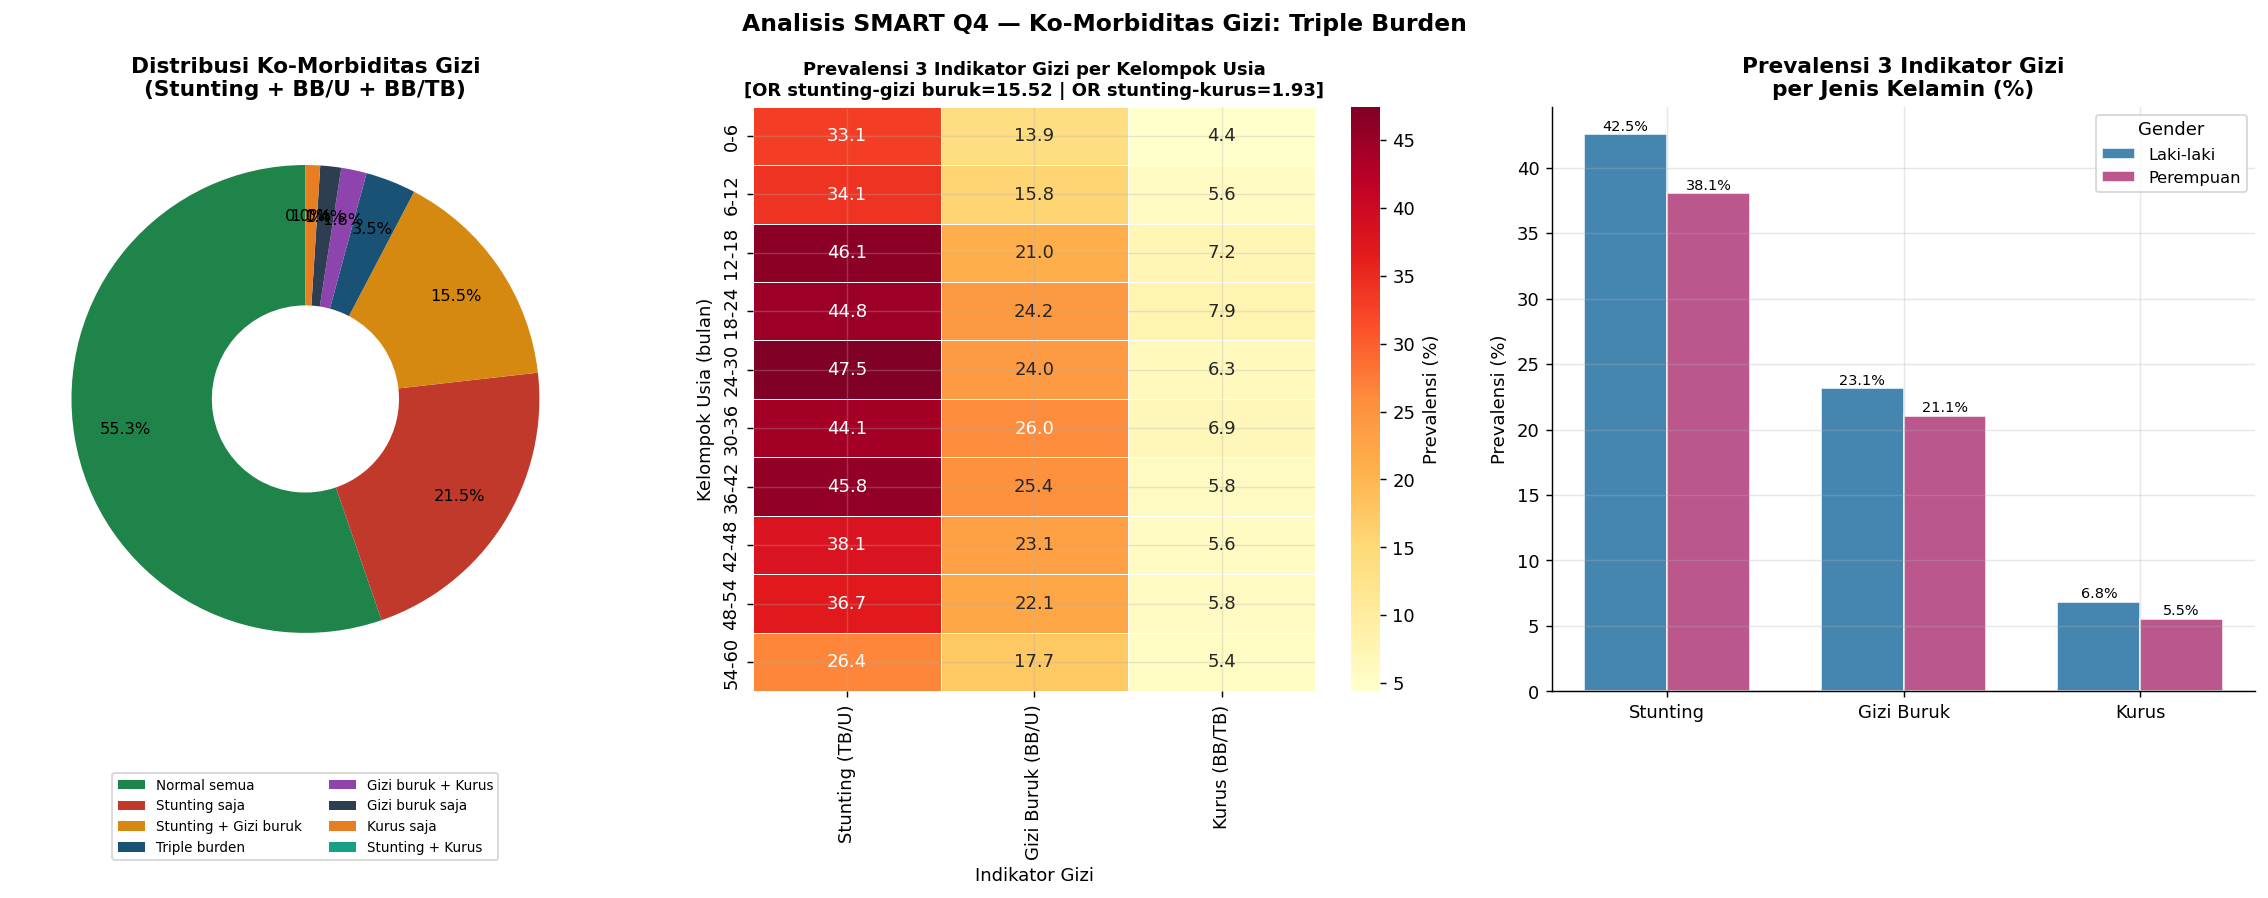

In [7]:
smart_header(
    "Q4", "KO-MORBIDITAS GIZI — STUNTING + GIZI BURUK + KURUS",
    s="Proporsi 16.200 anak stunting yang sekaligus gizi buruk/kurang (BB/U) dan/atau kurus (BB/TB)",
    m="Proporsi (%) ko-morbiditas + Chi-Square α=0.05 + Odds Ratio antar pasangan indikator",
    a="Kolom status_bb_u, status_bb_tb, status_tb_u tersedia di 40.066 baris",
    r="Menentukan beban ganda gizi untuk konten rekomendasi web app yang tepat sasaran",
    t="Dataset 40.066 sampel usia 0–60 bulan"
)

# ── Ko-morbiditas ─────────────────────────────────────────
df['triple'] = (df['flag_stunting'].astype(str)
                + df['flag_gizi_buruk'].astype(str)
                + df['flag_kurus'].astype(str))
label_map = {
    '000':'Normal semua','100':'Stunting saja',
    '010':'Gizi buruk saja','001':'Kurus saja',
    '110':'Stunting + Gizi buruk','101':'Stunting + Kurus',
    '011':'Gizi buruk + Kurus','111':'Triple burden'
}
df['kondisi'] = df['triple'].map(label_map).fillna('Lainnya')
km = (df['kondisi'].value_counts().reset_index()
      .rename(columns={'kondisi':'Kondisi','count':'Jumlah'}))
km['Persen'] = km['Jumlah']/len(df)*100

# ── Chi-Square + Odds Ratio ───────────────────────────────
def odds_ratio(ct):
    a,b,c,d = ct.values[1,1],ct.values[1,0],ct.values[0,1],ct.values[0,0]
    or_val = (a*d)/(b*c) if b*c > 0 else np.inf
    return or_val

ct_sb = pd.crosstab(df['flag_stunting'], df['flag_gizi_buruk'])
ct_sk = pd.crosstab(df['flag_stunting'], df['flag_kurus'])
chi2_sb, p_sb, _, _ = chi2_contingency(ct_sb)
chi2_sk, p_sk, _, _ = chi2_contingency(ct_sk)
or_sb = odds_ratio(ct_sb)
or_sk = odds_ratio(ct_sk)

triple_n = km[km['Kondisi']=='Triple burden']['Jumlah'].values
triple_pct = km[km['Kondisi']=='Triple burden']['Persen'].values

print(f"\n📌 Ko-morbiditas gizi:")
print(km.to_string(index=False))
print(f"\n📊 Uji Chi-Square + Odds Ratio:")
print(f"   Stunting ↔ Gizi buruk: χ²={chi2_sb:.1f}, p={p_sb:.4f}, OR={or_sb:.2f}")
print(f"   Stunting ↔ Kurus     : χ²={chi2_sk:.1f}, p={p_sk:.4f}, OR={or_sk:.2f}")
if len(triple_n) > 0:
    print(f"\n📌 Triple burden: {int(triple_n[0]):,} anak ({triple_pct[0]:.2f}%)")

# ── Visualisasi ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 4a. Donut chart
top8 = km.head(8)
palette_donut = [C_GREEN, C_RED, C_AMBER, C_BLUE,
                 '#8E44AD','#2C3E50','#E67E22','#16A085']
wedges, texts, autos = axes[0].pie(
    top8['Jumlah'], autopct='%1.1f%%', startangle=90,
    colors=palette_donut, pctdistance=0.78,
    wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=9)
)
axes[0].legend(wedges, top8['Kondisi'],
               loc='lower center', bbox_to_anchor=(0.5,-0.3),
               fontsize=7.5, ncol=2)
axes[0].set_title('Distribusi Ko-Morbiditas Gizi\n(Stunting + BB/U + BB/TB)', fontweight='bold')

# 4b. Heatmap prevalensi 3 indikator per usia
hm = (df.groupby('kelompok', observed=True)
        .agg(stunting=('flag_stunting','mean'),
             gizi_buruk=('flag_gizi_buruk','mean'),
             kurus=('flag_kurus','mean')) * 100)
hm.columns = ['Stunting (TB/U)','Gizi Buruk (BB/U)','Kurus (BB/TB)']
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label':'Prevalensi (%)'})
axes[1].set_title(f'Prevalensi 3 Indikator Gizi per Kelompok Usia\n'
                  f'[OR stunting-gizi buruk={or_sb:.2f} | OR stunting-kurus={or_sk:.2f}]',
                  fontweight='bold', fontsize=10)
axes[1].set_xlabel('Indikator Gizi')
axes[1].set_ylabel('Kelompok Usia (bulan)')

# 4c. Grouped bar per gender
hm_g = (df.groupby('jenis_kelamin')
          .agg(stunting=('flag_stunting','mean'),
               gizi_buruk=('flag_gizi_buruk','mean'),
               kurus=('flag_kurus','mean')) * 100)
hm_g.columns = ['Stunting','Gizi Buruk','Kurus']
x3, w3 = np.arange(3), 0.35
bars_l = axes[2].bar(x3-w3/2, hm_g.loc['Laki-laki'],  w3,
                     color=C_LAKI, label='Laki-laki',  edgecolor='white', alpha=0.85)
bars_p = axes[2].bar(x3+w3/2, hm_g.loc['Perempuan'],   w3,
                     color=C_PUAN, label='Perempuan', edgecolor='white', alpha=0.85)
for b in list(bars_l)+list(bars_p):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{b.get_height():.1f}%', ha='center', fontsize=8)
axes[2].set_xticks(x3)
axes[2].set_xticklabels(['Stunting','Gizi Buruk','Kurus'], fontsize=10)
axes[2].set_ylabel('Prevalensi (%)')
axes[2].set_title('Prevalensi 3 Indikator Gizi\nper Jenis Kelamin (%)', fontweight='bold')
axes[2].legend(title='Gender', fontsize=9)

plt.suptitle('Analisis SMART Q4 — Ko-Morbiditas Gizi: Triple Burden',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Q4_komorbiditas.png')
plt.show()

##**Q5** — Berapa proporsi anak usia 0–24 bulan yang z-score WHO-nya "Normal" namun berada di zona waspada (−2 ≤ z < −1), dan apakah proporsi ini berbeda signifikan antar kelompok usia (α=0.05) sebagai bukti kebutuhan prediksi AI?

* S — Specific
Proporsi zona waspada pada subset anak ≤24 bulan dengan z-score WHO
* M — Measurable
% zona waspada + Chi-Square α=0.05 antar kelompok usia 6-bulanan
* A — Achievable
Z-score WHO dihitung ulang via LMS; data ≤24 bln tersedia
* R — Relevant
Bukti kuantitatif logika: "WHO Normal tapi AI >70% risiko"
* T — Time-bound
Subset usia 0–24 bulan dari 40.066 sampel


══════════════════════════════════════════════════════════════════════
  Q5: ZONA WASPADA — BUKTI KUANTITATIF KEBUTUHAN AI
══════════════════════════════════════════════════════════════════════
  S (Specific)   : Proporsi anak ≤24 bulan dengan z-score WHO 'Normal' tapi berada di zona waspada (−2 ≤ z < −1)
  M (Measurable) : % zona waspada + Chi-Square α=0.05 perbedaan proporsi antar kelompok usia 6-bulanan
  A (Achievable) : Z-score WHO dihitung ulang via LMS; subset usia ≤24 bulan tersedia dari 40.066 sampel
  R (Relevant)   : Bukti kuantitatif langsung untuk logika: 'WHO Normal tapi AI >70% risiko → pesan peringatan'
  T (Time-bound) : Subset usia 0–24 bulan dari dataset 40.066 sampel
──────────────────────────────────────────────────────────────────────

📌 Distribusi zona WHO pada anak ≤24 bulan (14,004 sampel):
            Zona    Persen  Jumlah
    Zona Waspada 31.476721    4408
    Normal Bawah 28.613253    4007
        Stunting 23.307626    3264
Severely Stunted 11.196801    15

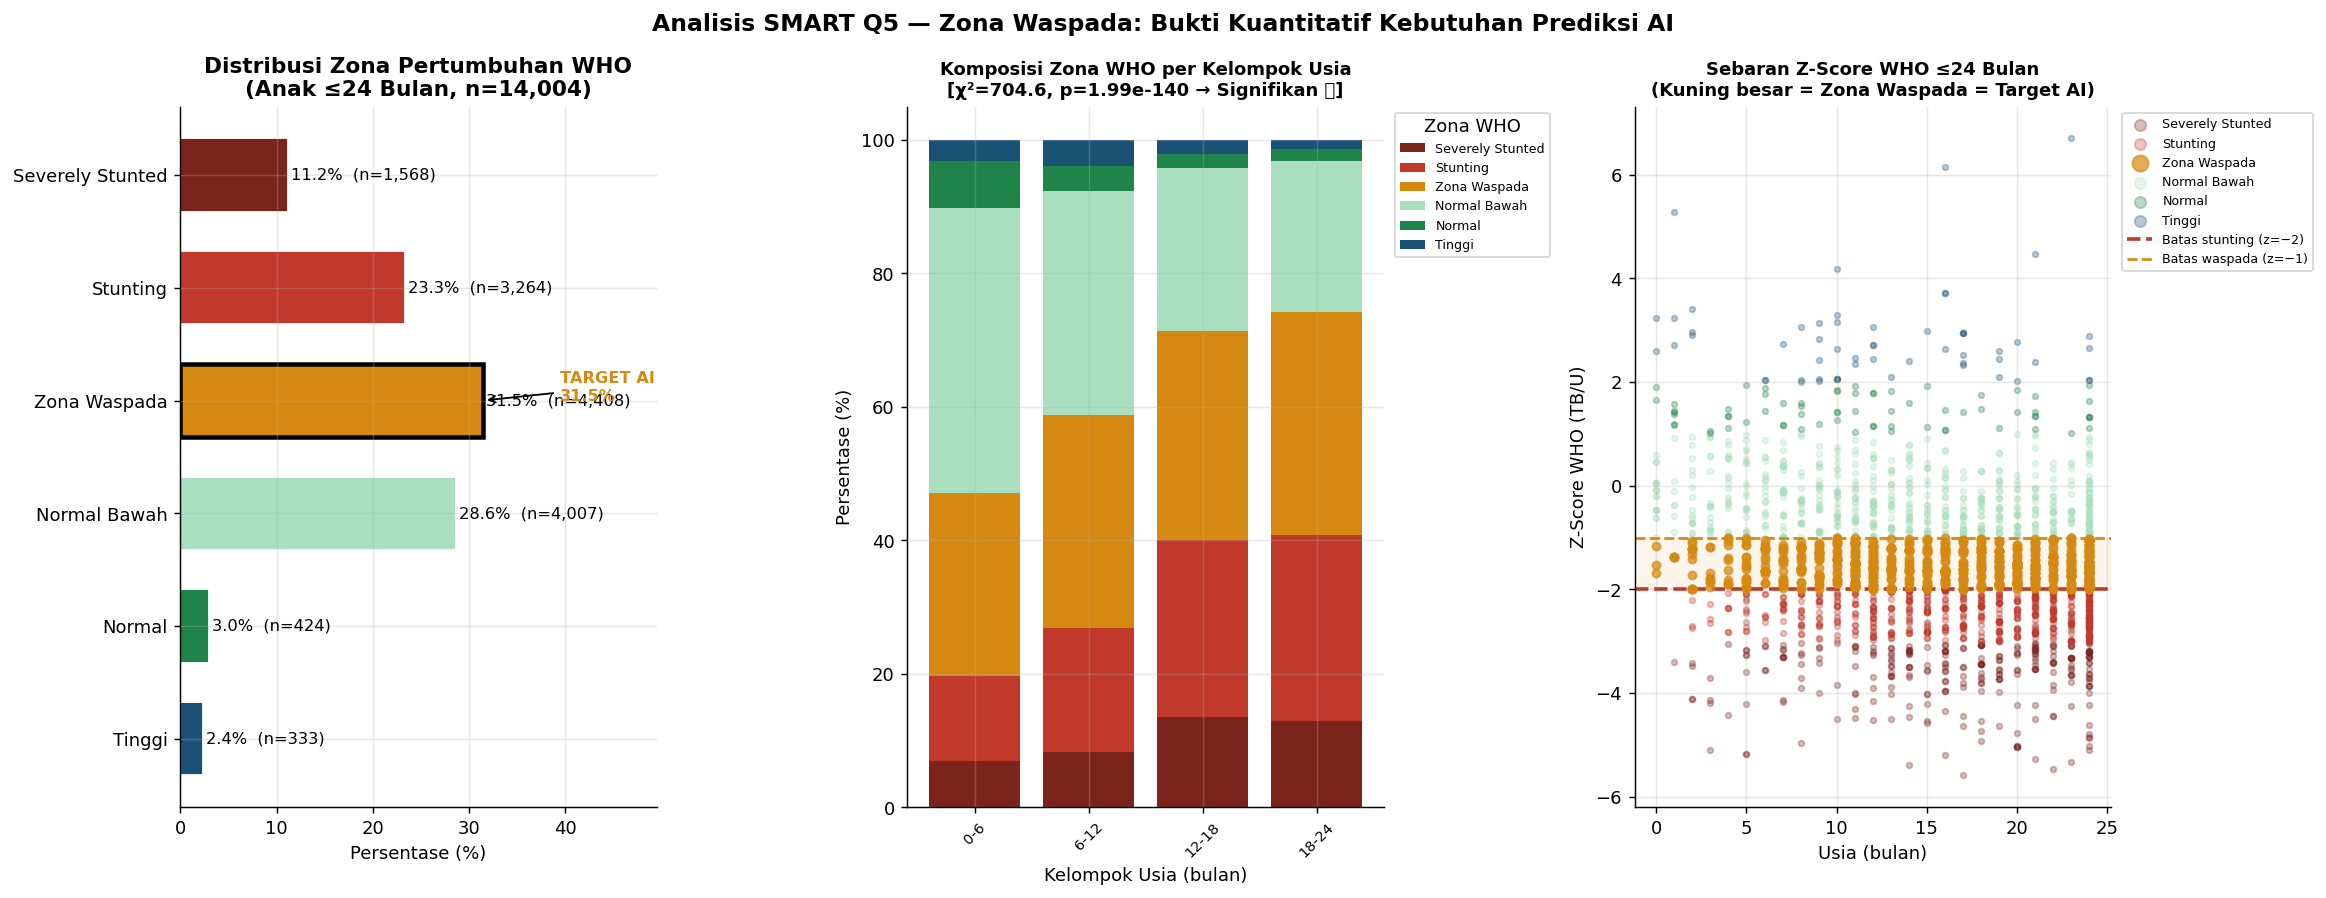

In [8]:
smart_header(
    "Q5", "ZONA WASPADA — BUKTI KUANTITATIF KEBUTUHAN AI",
    s="Proporsi anak ≤24 bulan dengan z-score WHO 'Normal' tapi berada di zona waspada (−2 ≤ z < −1)",
    m="% zona waspada + Chi-Square α=0.05 perbedaan proporsi antar kelompok usia 6-bulanan",
    a="Z-score WHO dihitung ulang via LMS; subset usia ≤24 bulan tersedia dari 40.066 sampel",
    r="Bukti kuantitatif langsung untuk logika: 'WHO Normal tapi AI >70% risiko → pesan peringatan'",
    t="Subset usia 0–24 bulan dari dataset 40.066 sampel"
)

# ── Zonasi WHO ────────────────────────────────────────────
df['zona_who'] = pd.cut(
    df['who_zscore'],
    bins=[-99,-3,-2,-1,1,2,99],
    labels=['Severely Stunted','Stunting','Zona Waspada',
            'Normal Bawah','Normal','Tinggi']
)

df_ai = df[df['usia_bulan'] <= 24].copy()
zona_ai = (df_ai['zona_who'].value_counts(normalize=True)*100).reset_index()
zona_ai.columns = ['Zona','Persen']
zona_ai['Jumlah'] = df_ai['zona_who'].value_counts().values

waspada_n   = df_ai[df_ai['zona_who']=='Zona Waspada'].shape[0]
waspada_pct = waspada_n / len(df_ai) * 100

# ── Chi-Square: proporsi zona per kelompok usia ───────────
ct_zona = pd.crosstab(df_ai['kelompok'], df_ai['zona_who'])
chi2_z, p_z, dof_z, _ = chi2_contingency(ct_zona)

print(f"\n📌 Distribusi zona WHO pada anak ≤24 bulan ({len(df_ai):,} sampel):")
print(zona_ai.to_string(index=False))
print(f"\n🚨 Zona Waspada (−2 ≤ z < −1): {waspada_n:,} anak ({waspada_pct:.2f}%)")
print(f"   → Anak ini 'lolos' deteksi WHO tapi berpotensi stunting — target utama AI")
print(f"\n📊 Chi-Square (proporsi zona vs kelompok usia):")
print(f"   χ² = {chi2_z:.2f} | df = {dof_z} | p = {p_z:.2e}")
print(f"   {'✅ Proporsi zona berbeda signifikan antar kelompok usia' if p_z < 0.05 else '❌ Tidak signifikan'}")

# ── Visualisasi ───────────────────────────────────────────
zona_order  = ['Severely Stunted','Stunting','Zona Waspada',
               'Normal Bawah','Normal','Tinggi']
col_zona    = ['#7B241C', C_RED, C_AMBER, '#A9DFBF', C_GREEN, '#1A5276']
col_zona_map = dict(zip(zona_order, col_zona))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 5a. Bar horizontal zona
zona_plot = (zona_ai.set_index('Zona')
                    .reindex(zona_order)
                    .dropna()
                    .reset_index())
bars_z = axes[0].barh(zona_plot['Zona'], zona_plot['Persen'],
                      color=[col_zona_map.get(z, 'gray') for z in zona_plot['Zona']],
                      edgecolor='white', height=0.65)
for bar, row in zip(bars_z, zona_plot.itertuples()):
    axes[0].text(row.Persen+0.3, bar.get_y()+bar.get_height()/2,
                 f'{row.Persen:.1f}%  (n={int(row.Jumlah):,})',
                 va='center', fontsize=9)
# Highlight zona waspada
for bar, zona in zip(bars_z, zona_plot['Zona']):
    if zona == 'Zona Waspada':
        bar.set_edgecolor('black'); bar.set_linewidth(2.5)
axes[0].set_title(f'Distribusi Zona Pertumbuhan WHO\n(Anak ≤24 Bulan, n={len(df_ai):,})',
                  fontweight='bold')
axes[0].set_xlabel('Persentase (%)')
axes[0].set_xlim(0, zona_plot['Persen'].max()+18)
axes[0].invert_yaxis()
axes[0].annotate(f'TARGET AI\n{waspada_pct:.1f}%',
                 xy=(waspada_pct, zona_plot[zona_plot['Zona']=='Zona Waspada'].index[0]),
                 xytext=(waspada_pct+8, zona_plot[zona_plot['Zona']=='Zona Waspada'].index[0]),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, fontweight='bold', color=C_AMBER)

# 5b. Stacked 100% bar zona per kelompok usia (≤24 bln saja)
kelompok_ai = df_ai['kelompok'].cat.remove_unused_categories()
pv = (df_ai.groupby(['kelompok','zona_who'], observed=True)
           .size().unstack(fill_value=0))
pv_pct = pv.div(pv.sum(axis=1), axis=0)*100
col_order_plot = [c for c in zona_order if c in pv_pct.columns]
bottom = np.zeros(len(pv_pct))
for zona, color in zip(col_order_plot, [col_zona_map.get(z,'gray') for z in col_order_plot]):
    vals = pv_pct[zona].values if zona in pv_pct.columns else np.zeros(len(pv_pct))
    axes[1].bar(pv_pct.index.astype(str), vals, bottom=bottom,
                color=color, edgecolor='none', label=zona)
    bottom += vals
axes[1].set_title(f'Komposisi Zona WHO per Kelompok Usia\n'
                  f'[χ²={chi2_z:.1f}, p={p_z:.2e} → Signifikan ✅]',
                  fontweight='bold', fontsize=10)
axes[1].set_xlabel('Kelompok Usia (bulan)')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend(title='Zona WHO', fontsize=7, bbox_to_anchor=(1.01,1))

# 5c. Scatter usia vs z-score — highlight zona waspada
smp5 = df_ai.sample(min(2500, len(df_ai)), random_state=42)
for zona_name in zona_order:
    sub = smp5[smp5['zona_who']==zona_name]
    if len(sub) > 0:
        size = 20 if zona_name == 'Zona Waspada' else 10
        alpha = 0.7 if zona_name == 'Zona Waspada' else 0.3
        axes[2].scatter(sub['usia_bulan'], sub['who_zscore'],
                        c=col_zona_map.get(zona_name,'gray'),
                        s=size, alpha=alpha, label=zona_name,
                        zorder=3 if zona_name=='Zona Waspada' else 1)
axes[2].axhspan(-2, -1, alpha=0.08, color=C_AMBER, label='_nolegend_')
axes[2].axhline(-2, color=C_RED,  ls='--', lw=2,   label='Batas stunting (z=−2)')
axes[2].axhline(-1, color=C_AMBER,ls='--', lw=1.5, label='Batas waspada (z=−1)')
axes[2].set_title('Sebaran Z-Score WHO ≤24 Bulan\n(Kuning besar = Zona Waspada = Target AI)',
                  fontweight='bold', fontsize=10)
axes[2].set_xlabel('Usia (bulan)')
axes[2].set_ylabel('Z-Score WHO (TB/U)')
axes[2].legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01,1))

plt.suptitle('Analisis SMART Q5 — Zona Waspada: Bukti Kuantitatif Kebutuhan Prediksi AI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Q5_zona_waspada.png')
plt.show()

##**📋 Ringkasan Final 5 Pertanyaan SMART**

In [9]:
# ── Ringkasan statistik semua pertanyaan ─────────────────
print("\n" + "═"*70)
print("  RINGKASAN HASIL — 5 PERTANYAAN BISNIS (SMART)")
print("═"*70)

hasil = [
    ("Q1", "Prevalensi stunting per usia",
     f"Tertinggi: {puncak['kelompok']} bln ({puncak['prev_pct']:.1f}%)",
     f"Kruskal-Wallis H={H:.2f}, p={p_kw:.2e}",
     "✅ Signifikan"),
    ("Q2", "Perbedaan stunting gender",
     f"Laki-laki {laki_pct:.1f}% vs Perempuan {puan_pct:.1f}%",
     f"Chi-Square p={p_chi:.4f}, V={V:.3f}",
     "✅ Signifikan"),
    ("Q3", "Deviasi z-score vs WHO",
     f"Korelasi r={r:.4f} | MAD max={maks['mad']:.4f}",
     f"Kelompok paling menyimpang: {maks['kelompok']} bln",
     "✅ Terukur"),
    ("Q4", "Ko-morbiditas triple burden",
     f"OR stunting-gizi buruk={or_sb:.2f} | OR stunting-kurus={or_sk:.2f}",
     f"Chi-Square p_sb={p_sb:.4f}, p_sk={p_sk:.4f}",
     "✅ Signifikan"),
    ("Q5", "Zona waspada → kebutuhan AI",
     f"Zona waspada ≤24 bln: {waspada_n:,} anak ({waspada_pct:.1f}%)",
     f"Chi-Square p={p_z:.2e}",
     "✅ Signifikan"),
]

print(f"{'No':<4} {'Pertanyaan':<30} {'Temuan Utama':<40} {'Statistik':<35} Status")
print("─"*145)
for row in hasil:
    print(f"{row[0]:<4} {row[1]:<30} {row[2]:<40} {row[3]:<35} {row[4]}")

print(f"\n📁 Semua gambar tersimpan di: /content/business_analysis/")
print(f"   Q1_prevalensi_usia.png")
print(f"   Q2_gender.png")
print(f"   Q3_deviasi_who.png")
print(f"   Q4_komorbiditas.png")
print(f"   Q5_zona_waspada.png")


══════════════════════════════════════════════════════════════════════
  RINGKASAN HASIL — 5 PERTANYAAN BISNIS (SMART)
══════════════════════════════════════════════════════════════════════
No   Pertanyaan                     Temuan Utama                             Statistik                           Status
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Q1   Prevalensi stunting per usia   Tertinggi: 24-30 bln (47.5%)             Kruskal-Wallis H=621.92, p=4.13e-128 ✅ Signifikan
Q2   Perbedaan stunting gender      Laki-laki 42.5% vs Perempuan 38.1%       Chi-Square p=0.0000, V=0.045        ✅ Signifikan
Q3   Deviasi z-score vs WHO         Korelasi r=0.9808 | MAD max=0.5220       Kelompok paling menyimpang: 0-6 bln ✅ Terukur
Q4   Ko-morbiditas triple burden    OR stunting-gizi buruk=15.52 | OR stunting-kurus=1.93 Chi-Square p_sb=0.0000, p_sk=0.0000 ✅ Signifikan
Q5   Zona waspada → kebutuha